# Hypothesis Test (2 Sample T-test)

Performing a hypothesis test on 20 before and after samples.  This method can be utilized to measure process improvement impacts on a process.

**Null Hypothesis (H0)**: Scores between the samples is the same. First 20 samples = last 20 samples

**Alternative Hypothesis (H1)**: Scores for the samples is different. 

<hr>

## Import data

In [25]:
# Libraries
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Data
df = pd.read_excel('my_data.xlsx')
df.head()

In [3]:
# Isolate the last twenty and the to last twenty
last_twenty = df['Scores'].iloc[-20:]
first_twenty = df['Scores'].iloc[-40:-20]

df_new = pd.DataFrame(columns=['first_twenty', 'last_twenty'], index=range(20))
df_new['first_twenty'] = first_twenty.values
df_new['last_twenty'] = last_twenty.values

df_new.head(20)

,first_twenty,last_twenty
0,40,66
1,39,59
2,47,47
3,39,46
4,39,56
5,51,64
6,50,51
7,45,61
8,33,48
9,52,57


In [21]:
first_twenty_mean = np.mean(first_twenty)
last_twenty_mean = np.mean(last_twenty)
print(f'The average score of the first twenty samples is: {first_twenty_mean}')
print(f'The average score of the last twenty samples is: {last_twenty_mean}')

The average score of the first twenty samples is: 46.4
The average score of the last twenty samples is: 58.3


In [22]:
df_new.describe().T

,count,mean,std,min,25%,50%,75%,max
first_twenty,20.0,46.4,8.580271,33.0,39.75,46.0,51.25,67.0
last_twenty,20.0,58.3,9.119672,46.0,52.50,56.5,63.25,80.0


<hr>

## Charting the data

In [6]:
x = range(20)
print(x)

range(0, 20)


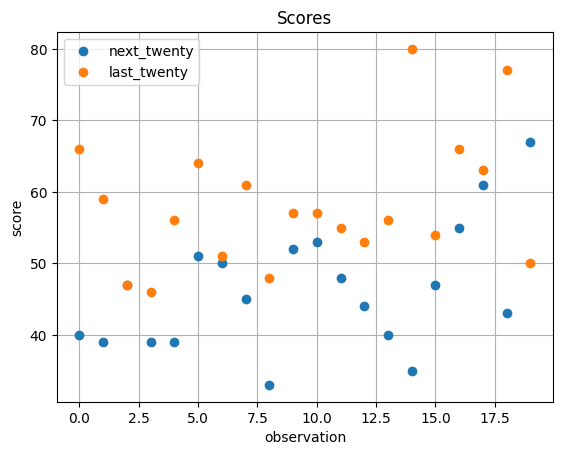

In [23]:
# Create the plots
plt.plot(x, first_twenty, 'o', label='next_twenty')
plt.plot(x, last_twenty, 'o', label='last_twenty')

# Labels and Titles
plt.xlabel('observation')
plt.ylabel('score')
plt.title('Scores')

# Legend
plt.legend()

# Show plot
plt.grid(True)
plt.show()

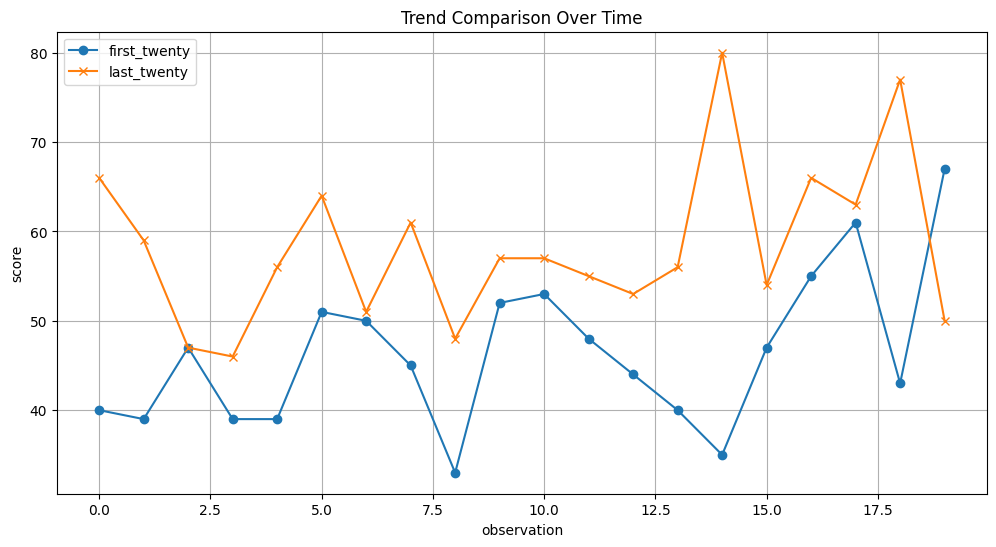

In [24]:
# Line plot 
plt.figure(figsize=(12,6))
plt.plot(df_new['first_twenty'], label='first_twenty', marker='o')
plt.plot(df_new['last_twenty'], label='last_twenty', marker='x')
plt.title('Trend Comparison Over Time')
plt.xlabel('observation')
plt.ylabel('score')
plt.legend()
plt.grid(True)
plt.show()

<Axes: >

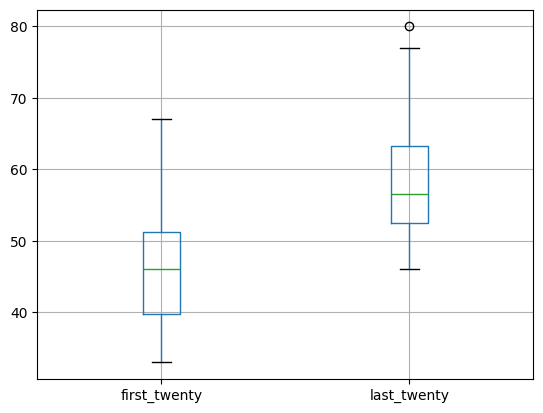

In [9]:
df_new.boxplot()

<Figure size 1200x600 with 0 Axes>

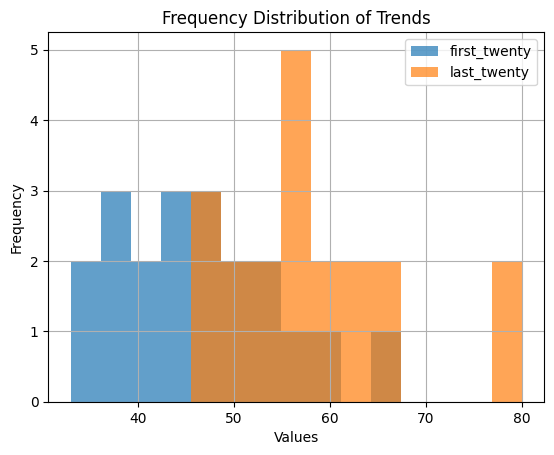

In [10]:
# Histogram for frequency distribution
plt.figure(figsize=(12, 6))
df_new.plot(kind='hist', alpha=0.7, bins=15)
plt.title('Frequency Distribution of Trends')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [11]:
differences = df_new['last_twenty'] - df_new['first_twenty']
mean_difference = differences.mean()
print(f'The mean difference is: {mean_difference}')

The mean difference is: 11.9


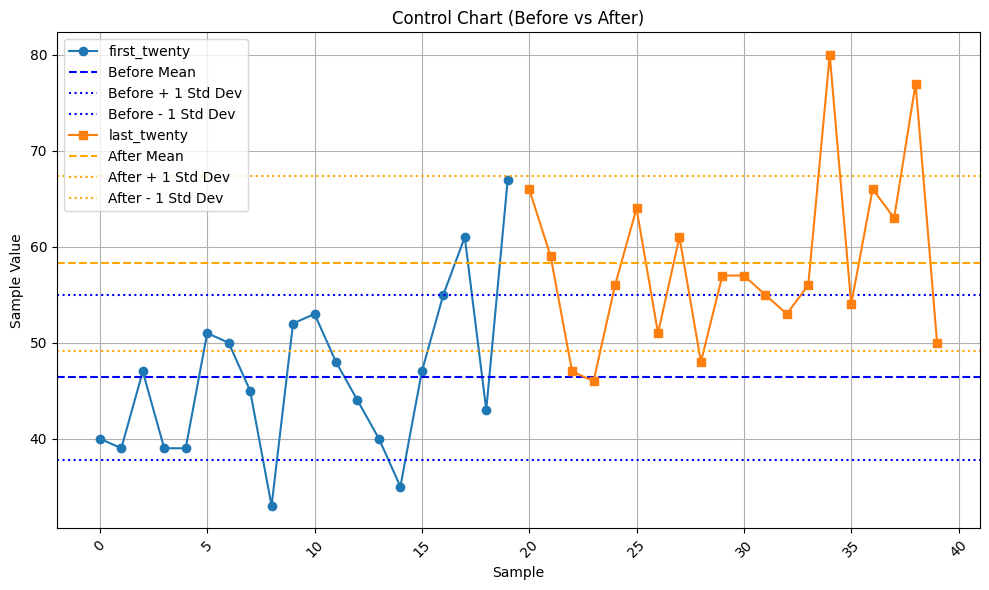

In [12]:
## Control Chart 

# Calculate mean and standard deviation for both columns
before_mean = df_new['first_twenty'].mean()
before_std = df_new['first_twenty'].std()
after_mean = df_new['last_twenty'].mean()
after_std = df_new['last_twenty'].std()

# Create the control chart
plt.figure(figsize=(10, 6))

# Plot the before data
plt.plot(df_new.index, df_new['first_twenty'], 'o-', label='first_twenty')
plt.axhline(y=before_mean, color='b', linestyle='--', label='Before Mean')
plt.axhline(y=before_mean + before_std, color='b', linestyle=':', label='Before + 1 Std Dev')
plt.axhline(y=before_mean - before_std, color='b', linestyle=':', label='Before - 1 Std Dev')

# Plot the after data with a shift of 20 points in the x-axis
plt.plot(df_new.index + 20, df_new['last_twenty'], 's-', label='last_twenty')
plt.axhline(y=after_mean, color='orange', linestyle='--', label='After Mean')
plt.axhline(y=after_mean + after_std, color='orange', linestyle=':', label='After + 1 Std Dev')
plt.axhline(y=after_mean - after_std, color='orange', linestyle=':', label='After - 1 Std Dev')

# Set labels and title
plt.xlabel('Sample')
plt.ylabel('Sample Value')
plt.title('Control Chart (Before vs After)')
plt.legend()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust x-axis limits to accommodate both sets of data
plt.xlim(-2, df_new.index.max() + 22)  # Add a buffer on both sides

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<b>Note: </b>Although control charts are typically used to check if a process is in control, there is information from the chart that can be beneficial.  It can help visualize and highlight the different means or help assess the stability of the data. 
</div>

<hr>

Test Assumptions

## Normality Test (Shapiro-Wilks Test)

**Null Hypothesis (H0)**: Data follows the normal distribution

**Alternative Hypothesis (H1):** Data does not follow the normal distribution

In [13]:
alpha = 1 - 0.95

In [14]:
# Create a function to read the p-value
def p_value_reader(p_value, alpha):
    """ 
    Interpret the p-value in a statistical context
    """

    # Raise errors
    if not (0 <= p_value <= 1):
        raise ValueError("p_value must be between 0 and 1")
    if not (0 <= alpha <= 1):
        raise ValueError("threshold must be between 0 and 1")

    # Evaluate the p_value
    if p_value < alpha:
        print(f'p-value ({p_value}) is less than the threshold ({round(alpha, 2)}).')
        print("Evidence suggests rejecting the null hypothesis")
    else:
        print(f'p-value ({p_value}) is greater than or equal to the threshold ({round(alpha, 2)}).')
        print("Not enough evidence to reject the null hypothesis")

In [15]:
# Shapiro Wilks Test for normality
stat, p_value = st.shapiro(df_new['first_twenty'])
print(f'The p-value is {p_value}')

p_value_reader(p_value, alpha)

The p-value is 0.5540755391120911
p-value (0.5540755391120911) is greater than or equal to the threshold (0.05).
Not enough evidence to reject the null hypothesis


In [16]:
# Shapiro Wilks Test for normality
stat, p_value = st.shapiro(df_new['last_twenty'])
print(f'The p-value is {p_value}')

p_value_reader(p_value, alpha)

The p-value is 0.13179683685302734
p-value (0.13179683685302734) is greater than or equal to the threshold (0.05).
Not enough evidence to reject the null hypothesis


✅ Passes normality assumption check

<hr>

## Equal Variance Test (Levene's Test)

**Null Hypothesis (H0)**: There is no difference in variance

**Alternative Hypothesis (H1):** There is a difference in the variance

In [17]:
# Levene's Test for Equal Variance
levene_stat, pvalue = st.levene(first_twenty, last_twenty)
p_value_reader(p_value, alpha=0.05)

p-value (0.13179683685302734) is greater than or equal to the threshold (0.05).
Not enough evidence to reject the null hypothesis


✅ sample have the same variance

💡 If there is not equal variance, you can perform Welch's T-test below by changing 'equal_var'=False (example below)

<hr>

# T-test

<div class="alert alert-block alert-info">
<b>Note: </b>Depending on your data, choose the right t-test. 
</div>

## 2 tailed paired T-test

💡 This test is more appropriate two related samples.  This dataset has multiple different observations of students and probably not a good match for this test. 

**Null Hypothesis (H0)**: Scores between the samples is the same. First 20 samples = last 20 samples

**Alternative Hypothesis (H1)**: Scores for the samples is different. 

In [18]:
# Perform a paired t-test 
t_score, p_value = st.ttest_rel(a=df_new['first_twenty'], 
             b=df_new['last_twenty'],
             alternative='two-sided') # change this if the hypothesis is greater or less than. 

print(f'T-score: {t_score}')
p_value_reader(p_value, alpha=0.05)

T-score: -4.035820902138456
p-value (0.0007059976557173412) is less than the threshold (0.05).
Evidence suggests rejecting the null hypothesis


<hr>

## 2 tailed T-test (equal variance)

💡 This test is more appropriate for this dataset of independent samples. This test assumes equal variance.

<div class="alert alert-block alert-info">
<b>Note: </b>If your dataset did not pass the variance assumption above, perform a Welch's t-test by changing the `equal_var`=False 
</div>

In [19]:
# Perform t-test
t_score, p_value = st.ttest_ind(a=df_new['first_twenty'],
                                b=df_new['last_twenty'],
                                alternative='two-sided') # change this if the hypothesis is greater or less than.

print(f'T-score: {t_score}')
p_value_reader(p_value, alpha=0.05)

T-score: -4.250142662929497
p-value (0.0001335202487423914) is less than the threshold (0.05).
Evidence suggests rejecting the null hypothesis


**Conclusion:**

* Use a 2 tailed T-test for equal variance as the test
* ❌ Reject the Null Hypothesis, there is a difference in the means. 

<hr>

## 2 tailed T-test (unequal variance)

* This test below is just an example if the sample did not pass the varaince test.  This data did pass the variance assumption, so we would not use it here.

💡 This test is more appropriate for this dataset of independent samples. This test assumes unequal variance. 

In [20]:
# Perform t-test
t_score, p_value = st.ttest_ind(a=df_new['first_twenty'],
                                b=df_new['last_twenty'],
                                alternative='two-sided',
                                equal_var=False) # for unequal variance <------------------------------

print(f'T-score: {t_score}')
p_value_reader(p_value, alpha=0.05)

T-score: -4.250142662929497
p-value (0.00013422645172699333) is less than the threshold (0.05).
Evidence suggests rejecting the null hypothesis
